# 🧪 Ensemble Learning Lab: Bagging, Boosting, and Stacking (Classification)

## 🎯 Objective
In this task, you will **design, train, evaluate, and compare ensemble learning models** for a **classification problem** using real-world data.  
You will work with **Bagging**, **Boosting**, and **Stacking** techniques and analyze their performance using appropriate evaluation metrics.

---

## 📊 Dataset
- **Source**: :contentReference[oaicite:0]{index=0}  
- **Competition**: *Playground Series – Season 6, Episode 2*  
- **Problem Type**: **Supervised Classification**

🔗 Dataset link:  
[URL](https://www.kaggle.com/competitions/playground-series-s6e2/overview)

> **Note**: You must download the dataset using the Kaggle API or manually upload it to Colab/Jupyter.

---

## 🧠 Models to Implement

### 1️⃣ Bagging
- **Model**: `BaggingClassifier`
- **Base Estimator**: Decision Tree (recommended)
- Key hyperparameters to explore:
  - `n_estimators`
  - `max_samples`
  - `max_features`
  - `bootstrap`

---

### 2️⃣ Boosting Models

#### a) AdaBoost
- **Model**: `AdaBoostClassifier`
- Base estimator: Decision Tree (stump recommended)
- Tune:
  - `n_estimators`
  - `learning_rate`

#### b) Gradient Boosting
- **Model**: `GradientBoostingClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`

#### c) XGBoost
- **Model**: `XGBClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`
  - `colsample_bytree`

> ⚠️ Handle class imbalance if present.

---

### 3️⃣ Stacking
- **Model**: `StackingClassifier`
- **Base learners** (example):
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
- **Meta-learner**:
  - Logistic Regression (recommended)

---

## ⚙️ Task Instructions

### 🔹 Step 1: Data Preparation
- Load training data
- Separate features and target
- Handle missing values (if any)
- Encode categorical variables
- Perform train/validation split
- Apply feature scaling where necessary

---

### 🔹 Step 2: Model Training
- Train **each ensemble model independently**
- Use **cross-validation** where appropriate
- Record training time and key hyperparameters

---

### 🔹 Step 3: Evaluation Metrics
Evaluate all models using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

---

### 🔹 Step 4: Model Comparison
Create a **comparison table** that includes:
- Model name
- Accuracy
- F1-score
- ROC-AUC
- Training time
- Key observations

---

## 📈 Analysis & Discussion (Required)

Answer the following:
1. Which ensemble method performed best and why?
2. How does **bagging** differ from **boosting** in terms of bias and variance?
3. Did stacking outperform individual ensemble models?
4. Which model would you choose for deployment and why?
5. What are the computational trade-offs between these methods?

---

## 📝 Deliverables
- Fully executable notebook
- Clean, well-documented code
- Final comparison table
- Written analysis and conclusions

---

## ⭐ Bonus (Optional)
- Perform **hyperparameter tuning** using GridSearchCV or RandomizedSearchCV
- Plot **ROC curves** for all models
- Analyze **feature importance** for boosting models

---

🎓 **Learning Outcome**  
By completing this task, you will gain hands-on experience with advanced ensemble techniques and develop a strong intuition for **when and why to use bagging, boosting, or stacking in classification problems**.

## Install Dependecies

In [1]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle competitions download -c playground-series-s6e2
!unzip playground-series-s6e2.zip

  0% 0.00/10.2M [00:00<?, ?B/s]
100% 10.2M/10.2M [00:00<00:00, 1.05GB/s]
Archive:  playground-series-s6e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


## Explore the Data

In [3]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [4]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [7]:
train.isna().sum()

,0
id,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


## Encode the Target

In [8]:
print(train["Heart Disease"].value_counts())
print(train["Heart Disease"].unique())

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
['Presence' 'Absence']


In [9]:
train["Heart Disease"] = (train["Heart Disease"] == "Presence").astype(int)

print(train["Heart Disease"].value_counts())
print(train["Heart Disease"].value_counts(normalize=True).round(3))

Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.552
1    0.448
Name: proportion, dtype: float64


## Quick EDA

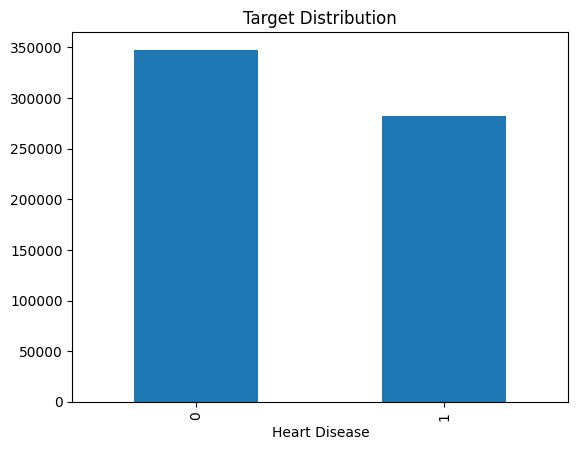

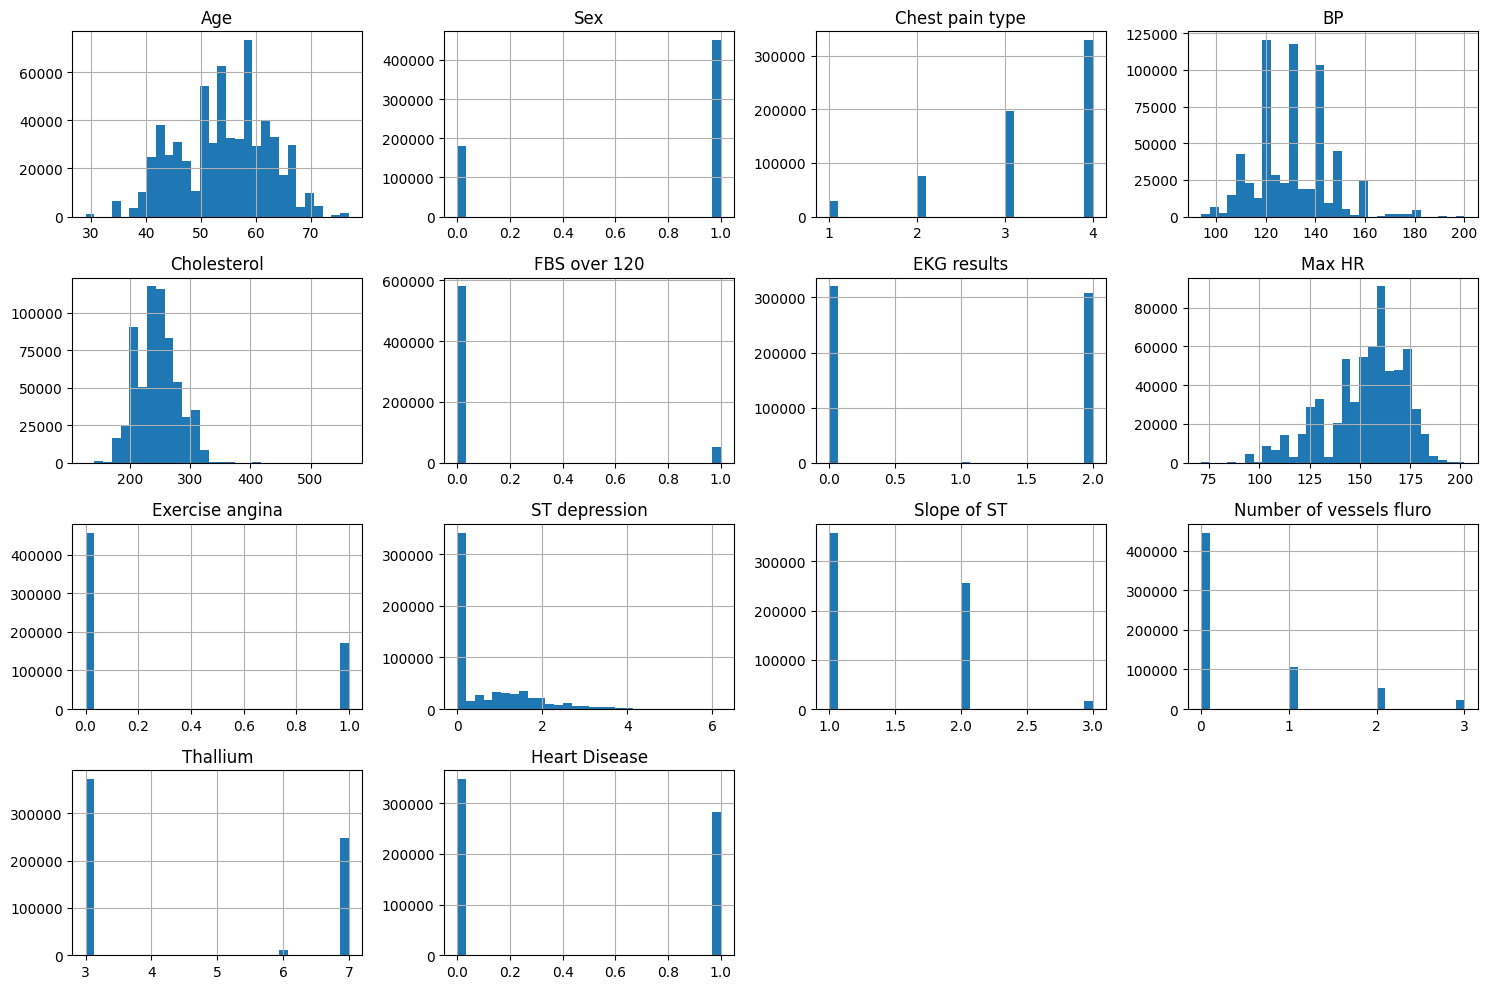

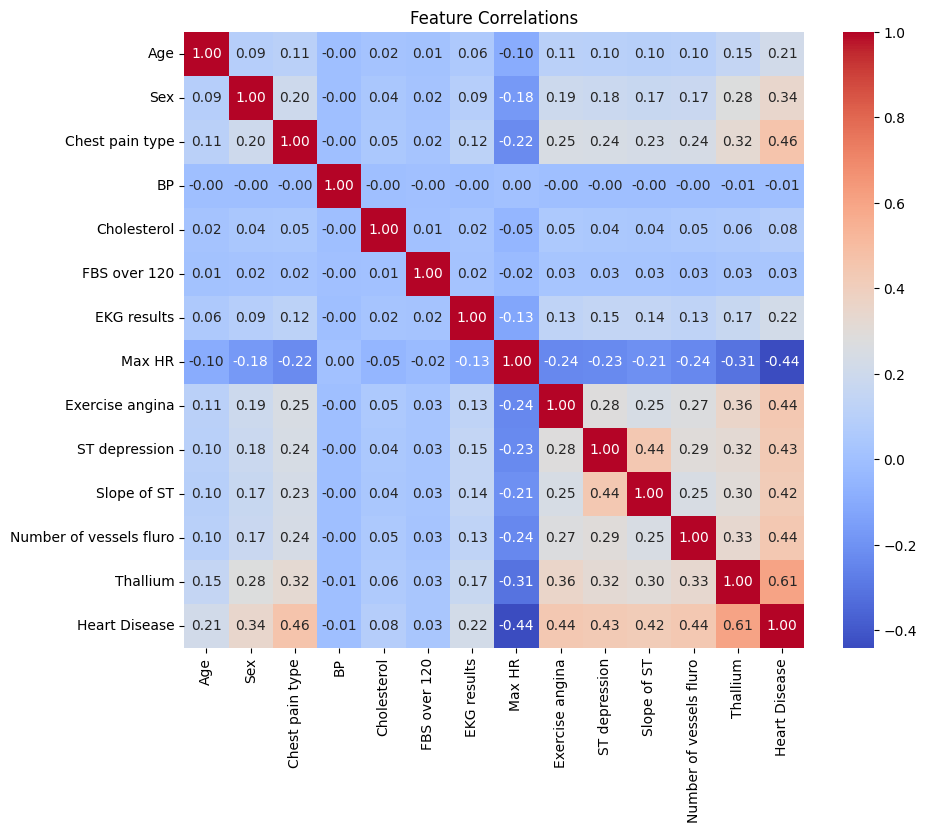

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 — Target distribution
train["Heart Disease"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

# 2 — Feature distributions by target
X_eda = train.drop(columns=["id"])
X_eda.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# 3 — Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_eda.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

## Train/Test Split

In [10]:
X = train.drop(columns=["id", "Heart Disease"])
y = train["Heart Disease"]

X_test_final = test.drop(columns=["id"])

print(X.shape)
print(y.shape)
print(X_test_final.shape)

(630000, 13)
(630000,)
(270000, 13)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves 55/45 ratio in both splits
)

print(X_train.shape)
print(X_val.shape)
print(y_train.mean().round(3))
print(y_val.mean().round(3))

(504000, 13)
(126000, 13)
0.448
0.448


## Evaluation Metrics

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import time

all_results = []

def evaluate_model(name, model, X_val, y_val, train_time):
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    result = {
        "Model"        : name,
        "Accuracy"     : round(accuracy_score(y_val, y_pred), 4),
        "Precision"    : round(precision_score(y_val, y_pred), 4),
        "Recall"       : round(recall_score(y_val, y_pred), 4),
        "F1"           : round(f1_score(y_val, y_pred), 4),
        "ROC-AUC"      : round(roc_auc_score(y_val, y_proba), 4),
        "Train Time(s)": round(train_time, 2)
    }

    for k, v in result.items():
        print(f"{k:<15}: {v}")

    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["Absence", "Presence"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return result

## Training Models

Model          : Bagging
Accuracy       : 0.8849
Precision      : 0.8817
Recall         : 0.8585
F1             : 0.87
ROC-AUC        : 0.9513
Train Time(s)  : 152.66


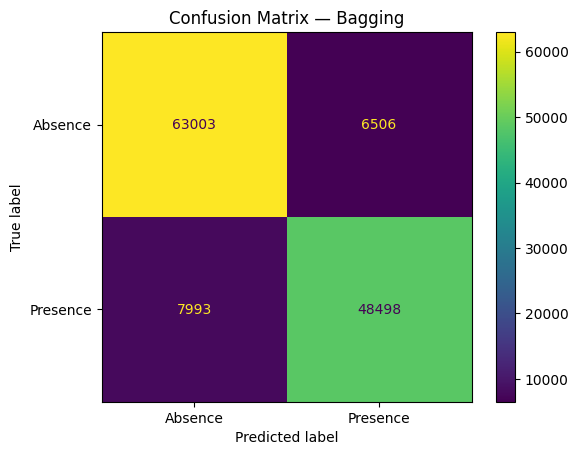

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

start = time.time()

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("Bagging", bagging, X_val, y_val, train_time))

Model          : AdaBoost
Accuracy       : 0.8878
Precision      : 0.8856
Recall         : 0.8609
F1             : 0.873
ROC-AUC        : 0.9544
Train Time(s)  : 60.75


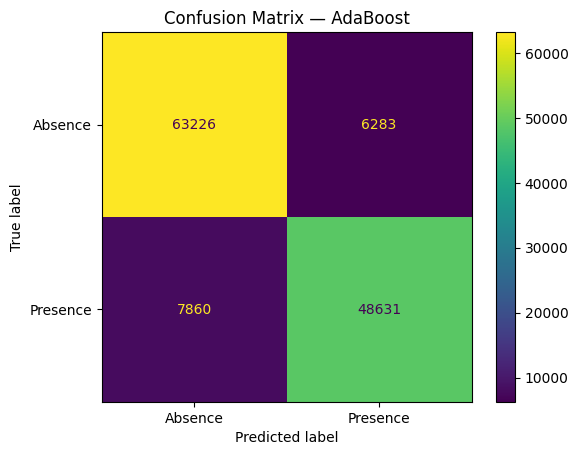

In [17]:
from sklearn.ensemble import AdaBoostClassifier

start = time.time()

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
adaboost.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("AdaBoost", adaboost, X_val, y_val, train_time))

Model          : GradientBoosting
Accuracy       : 0.8894
Precision      : 0.8824
Recall         : 0.8693
F1             : 0.8758
ROC-AUC        : 0.9557
Train Time(s)  : 178.88


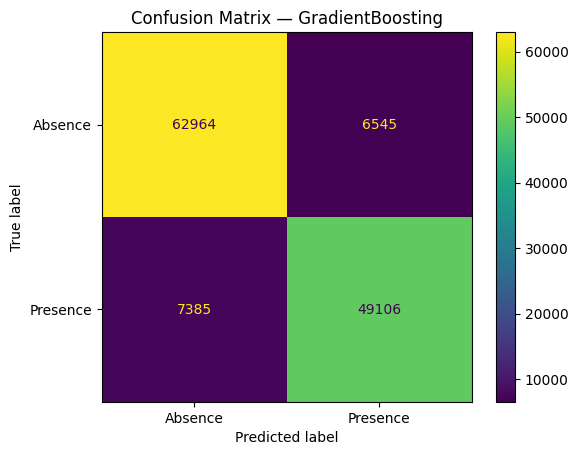

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

start = time.time()

gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbm.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("GradientBoosting", gbm, X_val, y_val, train_time))

Model          : XGBoost
Accuracy       : 0.8889
Precision      : 0.8702
Recall         : 0.8841
F1             : 0.8771
ROC-AUC        : 0.9558
Train Time(s)  : 9.53


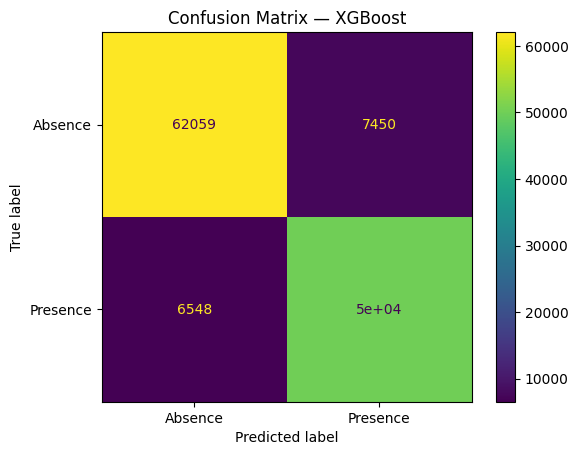

In [19]:
!pip install xgboost -q
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

start = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("XGBoost", xgb, X_val, y_val, train_time))

Model          : Stacking
Accuracy       : 0.8881
Precision      : 0.8819
Recall         : 0.8664
F1             : 0.8741
ROC-AUC        : 0.9546
Train Time(s)  : 900.91


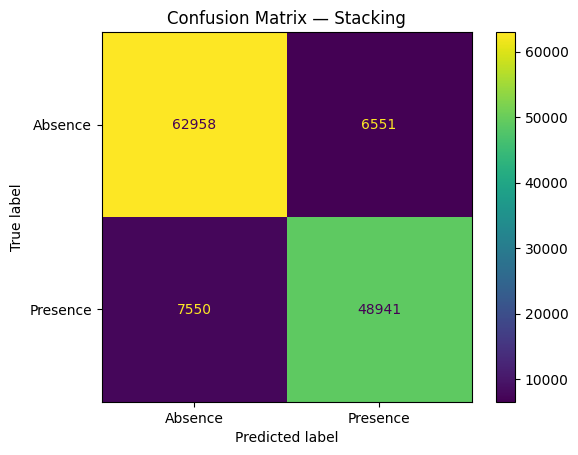

In [20]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

base_learners = [
    ("lr",  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ("rf",  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("gbm", GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42))
]

meta_learner = LogisticRegression()

start = time.time()

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False
)
stacking.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("Stacking", stacking, X_val, y_val, train_time))

## Save Results

In [21]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time(s)
0,XGBoost,0.8889,0.8702,0.8841,0.8771,0.9558,9.53
1,GradientBoosting,0.8894,0.8824,0.8693,0.8758,0.9557,178.88
2,Stacking,0.8881,0.8819,0.8664,0.8741,0.9546,900.91
3,AdaBoost,0.8878,0.8856,0.8609,0.8730,0.9544,60.75
4,Bagging,0.8849,0.8817,0.8585,0.8700,0.9513,152.66
5,Bagging,0.8849,0.8817,0.8585,0.8700,0.9513,154.44


In [24]:
pred_proba = xgb.predict_proba(X_test_final)[:, 1]
pred_proba[:5]

array([0.9518532 , 0.00932854, 0.98516417, 0.00605298, 0.22320297],
      dtype=float32)

In [26]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": pred_proba
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Heart Disease
0,630000,0.951853
1,630001,0.009329
2,630002,0.985164
3,630003,0.006053
4,630004,0.223203


## Submit

In [27]:
!kaggle competitions submit -c playground-series-s6e2 -f submission.csv -m "XGBoost baseline"

100% 4.61M/4.61M [00:00<00:00, 15.4MB/s]
Successfully submitted to Predicting Heart Disease